## CMAPSS Predictive Maintenance - ML Pipeline
### Notebook 2: RUL Regression

In [0]:
"""REGRESSION
  - Model : XGBoost | Tracking: MLflow
  - INput: gold_ml_train, gold_ml_test
"""

import mlflow
import mlflow.xgboost
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

mlflow.set_experiment("/cmapss_rul_regression")


print(f"XGBoost version: {xgb.__version__}")
print(f"MLflow version:  {mlflow.__version__}")
print("MLflow experiment set: /cmapss_rul_regression")

XGBoost version: 3.2.0
MLflow version:  3.8.1
MLflow experiment set: /cmapss_rul_regression


In [0]:
"""Load ML tables and covert to pandas"""

KEY_SENSORS = ["sensor_2", "sensor_3", "sensor_4", "sensor_7",
               "sensor_11", "sensor_12", "sensor_15", "sensor_17",
               "sensor_20", "sensor_21"]

ALL_SENSORS = [f"sensor_{i+1}" for i in range(21)]

roll_mean_5_cols  = [f"{s}_roll_mean_5"  for s in KEY_SENSORS]
roll_mean_10_cols = [f"{s}_roll_mean_10" for s in KEY_SENSORS]
roll_mean_30_cols = [f"{s}_roll_mean_30" for s in KEY_SENSORS]
roll_std_10_cols  = [f"{s}_roll_std_10"  for s in KEY_SENSORS]

FEATURE_COLS = (
    ["dataset_id_encoded",
     "op_setting_1", "op_setting_2", "op_setting_3"] +
    ALL_SENSORS +
    roll_mean_5_cols +
    roll_mean_10_cols +
    roll_mean_30_cols +
    roll_std_10_cols
)

REGRESSION_TARGET = "rul_capped"

# Load
train_df = spark.read.format("delta").table("cmapss_project.gold.gold_ml_train").toPandas()
test_df  = spark.read.format("delta").table("cmapss_project.gold.gold_ml_test").toPandas()

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")



Train shape: (160359, 70)
Test shape:  (707, 70)


In [0]:
"""Train/Validation Split
Stratify the dataset_id to ensure all 4 datasets represented in both
"""

X = train_df[FEATURE_COLS]
y = train_df[REGRESSION_TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=train_df["dataset_id_encoded"]
)

# Test SEt
X_test = test_df[FEATURE_COLS]
y_test = test_df[REGRESSION_TARGET]

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val: {X_val.shape} | y_val: {y_val.shape}")
print(f"X_test: {X_test.shape} | y_test: {y_test.shape}")


X_train: (128287, 65) | y_train: (128287,)
X_val: (32072, 65) | y_val: (32072,)
X_test: (707, 65) | y_test: (707,)


In [0]:
""" Run 1: Baseline XGBoost with default parameters"""

with mlflow.start_run(run_name="baseline_xgboost"):

    # Log the baseline run
    mlflow.log_param("run_type", "baseline")
    mlflow.log_param("rul_cap", 125)
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("n_features", len(FEATURE_COLS))

    params = {
        "n_estimators": 100,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "n_jobs": -1
    }

    mlflow.log_params(params)

    # Train
    model_baseline = xgb.XGBRegressor(**params)
    model_baseline.fit(
        X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
    )

    # Evaluate on validation set
    val_preds = model_baseline.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    val_mae = mean_absolute_error(y_val, val_preds)
    val_r2 = r2_score(y_val, val_preds)

    # Evaluate on test set
    test_preds = model_baseline.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_mae = mean_absolute_error(y_test, test_preds)
    test_r2 = r2_score(y_test, test_preds)

    # Log metrics to Mlflow
    mlflow.log_metric("val_rmse", round(val_rmse, 4))
    mlflow.log_metric("val_mae", round(val_mae, 4))
    mlflow.log_metric("val_r2", round(val_r2, 4))
    mlflow.log_metric("test_rmse", round(test_rmse, 4))
    mlflow.log_metric("test_mae", round(test_mae, 4))
    mlflow.log_metric("test_r2", round(test_r2, 4))

    # Log model to Mlflow
    mlflow.xgboost.log_model(model_baseline, name="model")

    print("=== Baseline XGBoost Results ===")
    print(f"Validation - RMSE: {val_rmse:.2f} | MAE: {val_mae:.2f} | R2: {val_r2:.4f}")
    print(f"Test - RMSE: {test_rmse:.2f} | MAE: {test_mae:.2f} | R2: {test_r2:.4f}")


🔗 View Logged Model at: https://dbc-10cea8d5-2939.cloud.databricks.com/ml/experiments/196624675591178/models/m-4e1fe9997a534e73a216dc5373203b54?o=7474644282565291
2026/04/23 20:37:44 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


=== Baseline XGBoost Results ===
Validation - RMSE: 18.05 | MAE: 13.09 | R2: 0.8083
Test - RMSE: 18.45 | MAE: 13.72 | R2: 0.8077


In [0]:
"""Run 2: Tuned XGBoost"""

with mlflow.start_run(run_name="tuned_xgboost"):
    mlflow.log_param("run_type", "tuned")
    mlflow.log_param("rul_cap", 125)
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("n_features", len(FEATURE_COLS))

    params_tuned = {
        "n_estimators": 500,
        "max_depth": 8,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 3,
        "gamma": 0.1,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "random_state": 42,
        "n_jobs": -1
    }

    mlflow.log_params(params_tuned)

    model_tuned = xgb.XGBRegressor(**params_tuned)
    model_tuned.fit(
        X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
    )

    val_preds_t = model_tuned.predict(X_val)
    val_rmse_t = np.sqrt(mean_squared_error(y_val, val_preds_t))
    val_mae_t = mean_absolute_error(y_val, val_preds_t)
    val_r2_t = r2_score(y_val, val_preds_t)

    test_preds_t = model_tuned.predict(X_test)
    test_rmse_t = np.sqrt(mean_squared_error(y_test, test_preds_t))
    test_mae_t = mean_absolute_error(y_test, test_preds_t)
    test_r2_t = r2_score(y_test, test_preds_t)

    mlflow.log_metric("val_rmse", round(val_rmse_t, 4))
    mlflow.log_metric("val_mae", round(val_mae_t, 4))
    mlflow.log_metric("val_r2", round(val_r2_t, 4))
    mlflow.log_metric("test_rmse", round(test_rmse_t, 4))
    mlflow.log_metric("test_mae", round(test_mae_t, 4))
    mlflow.log_metric("test_r2", round(test_r2_t, 4))

    mlflow.xgboost.log_model(model_tuned, name="model")

    print("=== Tuned XGBoost Results ===")
    print(f"Validation - RMSE: {val_rmse_t:.2f} | MAE: {val_mae_t:.2f} | R2: {val_r2_t:.4f}")
    print(f"Test - RMSE: {test_rmse_t:.2f} | MAE: {test_mae_t:.2f} | R2: {test_r2_t:.4f}")

🔗 View Logged Model at: https://dbc-10cea8d5-2939.cloud.databricks.com/ml/experiments/196624675591178/models/m-5c19e88f9e514ba1a70cd9e310895eff?o=7474644282565291
2026/04/23 20:55:50 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


=== Tuned XGBoost Results ===
Validation - RMSE: 16.38 | MAE: 11.42 | R2: 0.8421
Test - RMSE: 17.90 | MAE: 13.12 | R2: 0.8191


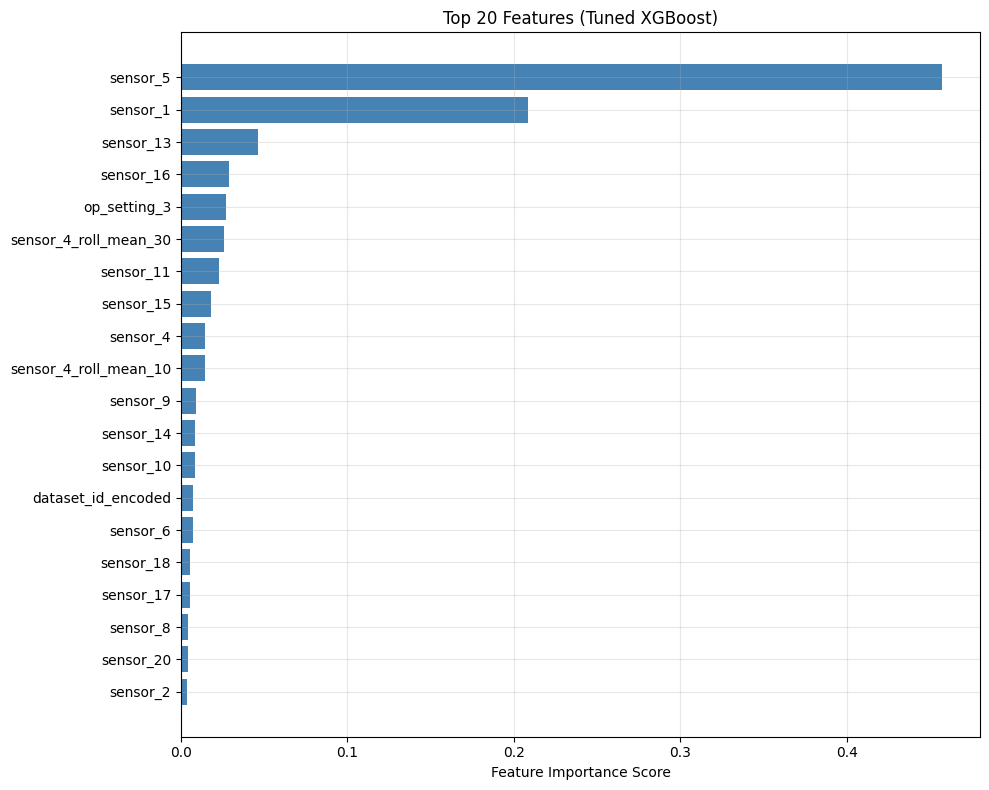


Top 10 features:
              feature  importance
             sensor_5    0.457297
             sensor_1    0.208737
            sensor_13    0.046538
            sensor_16    0.029015
         op_setting_3    0.026873
sensor_4_roll_mean_30    0.026072
            sensor_11    0.022876
            sensor_15    0.018047
             sensor_4    0.014296
sensor_4_roll_mean_10    0.014230


In [0]:
"""Feature importance from tuned model"""
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": model_tuned.feature_importances_
}).sort_values("importance", ascending=False).head(20)


fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="steelblue")
ax.set_xlabel("Feature Importance Score")
ax.set_title("Top 20 Features (Tuned XGBoost)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10).to_string(index=False))

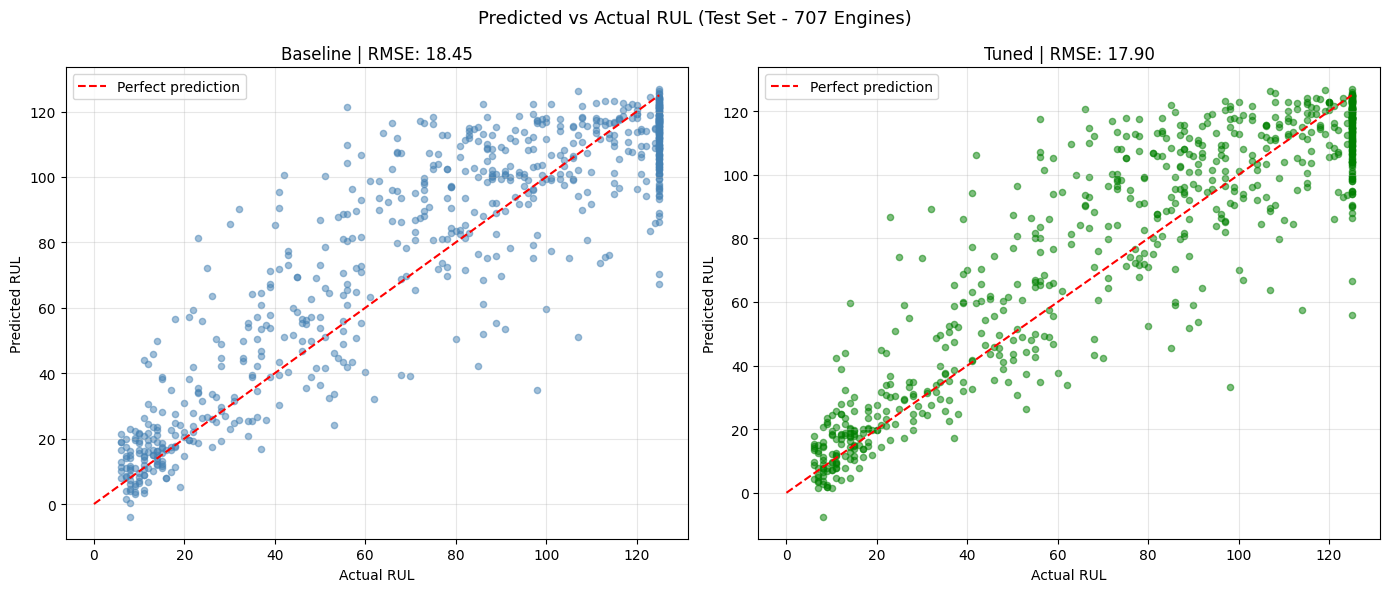

In [0]:
"""Prediction vs Actual RUL on Test Set"""

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Baseline
axes[0].scatter(y_test, model_baseline.predict(X_test), alpha=0.5, color="steelblue", s=20)
axes[0].plot([0, 125], [0, 125], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title(f"Baseline | RMSE: {test_rmse:.2f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Tuned
axes[1].scatter(y_test, model_tuned.predict(X_test), alpha=0.5, color="green", s=20)
axes[1].plot([0, 125], [0, 125], "r--", linewidth=1.5, label="Perfect prediction")
axes[1].set_xlabel("Actual RUL")
axes[1].set_ylabel("Predicted RUL")
axes[1].set_title(f"Tuned | RMSE: {test_rmse_t:.2f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Predicted vs Actual RUL (Test Set - 707 Engines)", fontsize=13)
plt.tight_layout()
plt.show()

In [0]:
"""Register best model in Mlflow"""

best_model = model_tuned if test_rmse_t < test_rmse else model_baseline
best_rmse = min(test_rmse_t, test_rmse)
best_run_name = "tuned" if test_rmse_t < test_rmse else "baseline"

print(f"Best model: {best_run_name} | Test RMSE: {best_rmse:.2f}")

from mlflow.models import infer_signature

signature = infer_signature(
    X_test,
    best_model.predict(X_test)
)

# Register with MLflow
with mlflow.start_run(run_name="register_best_model"):
    mlflow.xgboost.log_model(
        best_model, name="model", 
        input_example=X_test.iloc[:5],
        signature=signature,
        registered_model_name="cmapss_rul_regressor"
    )

    mlflow.log_metric("test_rmse", round(best_rmse, 4))
    mlflow.log_param("best_run", best_run_name)



Best model: tuned | Test RMSE: 17.90


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-10cea8d5-2939.cloud.databricks.com/ml/experiments/196624675591178/models/m-6e2d2911f4754a58ba542e0498ec592e?o=7474644282565291
Registered model 'cmapss_rul_regressor' already exists. Creating a new versio

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '1' of model 'workspace.default.cmapss_rul_regressor': https://dbc-10cea8d5-2939.cloud.databricks.com/explore/data/models/workspace/default/cmapss_rul_regressor/version/1?o=7474644282565291


In [0]:
# Per-dataset performace breakdown
test_df_results = test_df.copy()
test_df_results["predicted_rul"] = model_tuned.predict(X_test)
test_df_results["error"] = abs(test_df_results["predicted_rul"] - test_df_results["rul_capped"])

per_dataset = test_df_results.groupby("dataset_id").agg(
    rmse=("error", lambda x: np.sqrt((x**2).mean())),
    mae=("error", "mean"),
    engine_count=("unit_id", "count")
).round(2)

print("Per-dataset RMSE breakdown:")
print(per_dataset)

# Log per-dataset metrics to MLflow for the best run
with mlflow.start_run(run_name="per_dataset_analysis"):
    for dataset_id, row in per_dataset.iterrows():
        mlflow.log_metric(f"rmse_{dataset_id}", round(row["rmse"], 4))
        mlflow.log_metric(f"mae_{dataset_id}",  round(row["mae"], 4))
    
    mlflow.log_param("key_finding", 
        "Multi-condition datasets FD002/FD004 harder to predict than single-condition FD001/FD003")
    
    print("Per-dataset metrics logged to MLflow.")

Per-dataset RMSE breakdown:
             rmse    mae  engine_count
dataset_id                            
FD001       16.03  11.12           100
FD002       17.62  13.32           259
FD003       15.49  11.25           100
FD004       19.72  14.47           248
Per-dataset metrics logged to MLflow.
